# Enrichment Analyses
# Phase 1 vs. Phase 1

using [clusterProfiler](https://github.com/YuLab-SMU/clusterProfiler) R package

**Two analyses**
1. [Gene Set Enrichment Analysis](#Gene-Set-Enrichment-Analysis-(GSEA))
2. [Over-Representation Analysis](#Over-Representation-Analysis)

# Gene Set Enrichment Analysis (GSEA)

uses an entire ranked list (by log2FoldChange) of genes to see if pathway genes cluster at the top or bottom

#### Are *pathways* generally over- or under-expressed in a given treatment?

## 0. load libraries

In [2]:
library(tidyverse)
library(clusterProfiler) # for GSEA()
library(enrichplot) # for enrichment visuals
library(GO.db) # for gene ontology database
library(UpSetR) # for Cvirginica annotations
library(patchwork) # for arranging multiple plots

## 1. read in CSVs

read in GO annotation data

In [3]:
# col1 = gene ID
# col2 = GO ID 
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
head(gene2go)

,gene,Gene.Ontology.IDs
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


re-format for correct input for `GSEA()` - two columns, one for GO term and one for gene ID

In [4]:
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ",\\s*|;\\s*|`")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

class(term2gene)
str(term2gene)
head(term2gene)

[1] "tbl_df"     "tbl"        "data.frame"

tibble [39,588 × 2] (S3: tbl_df/tbl/data.frame)
 $ term: chr [1:39588] "GO:0005261" "GO:0005886" "GO:0030001" "GO:0098655" ...
 $ gene: chr [1:39588] "LOC111099029" "LOC111099029" "LOC111099029" "LOC111099029" ...


term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


get term names for GO IDs

In [5]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


read in *all* genes from DESeq output (not just DEGs)

In [7]:
##### comparisons vs. control
# warm vs. control
w.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_cont.csv')

# both vs. control
b.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.both_v_cont.csv')

# hyp vs. control
h.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_cont.csv')

##### other comparisons
# hyp vs. both
h.b <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_both.csv')

# warm vs. both
w.b <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.warm_v_both.csv')

# warm vs. hyp
w.h <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/p1.hyp_v_warm.csv')

## 2. Formatting CSVs
input to `gsea()` is an order ranked geneList - I'm going to rank by log2FoldChange

In [12]:
# data needs to be a numeric vector
# create function for above cell block so can easily apply to other data
format_geneList <- function(df) {
    geneList <- df$log2FoldChange 
    # Set gene IDs as names
    names(geneList) <- df$Gene
    
    # Sort in decreasing order
    geneList <- sort(geneList, decreasing = TRUE)

    return(geneList)
    }

In [13]:
w.c_geneList <- format_geneList(w.c)
h.c_geneList <- format_geneList(h.c)
b.c_geneList <- format_geneList(b.c)
h.b_geneList <- format_geneList(h.b)
w.b_geneList <- format_geneList(w.b)
w.h_geneList <- format_geneList(w.h)

# check that it worked
class(w.c_geneList)
head(w.c_geneList)

[1] "numeric"

LOC144620727 LOC144621863 LOC144627481 LOC144624489 LOC111110618 LOC144622232 
    22.35143     22.10477     21.95536     21.74879     21.42696     21.40091

## 3. Run GSEA

### Warm vs. Control

In [14]:
# warm vs control
gsea_res_w.c <- GSEA(
    geneList = w.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_w.c)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.89% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0030527,GO:0030527,structural constituent of chromatin,63,0.9837304,1.87382,3.941269e-05,0.02077049,0.02077049,81,"tags=3%, list=0%, signal=3%",LOC144620727/LOC111118772


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>.”


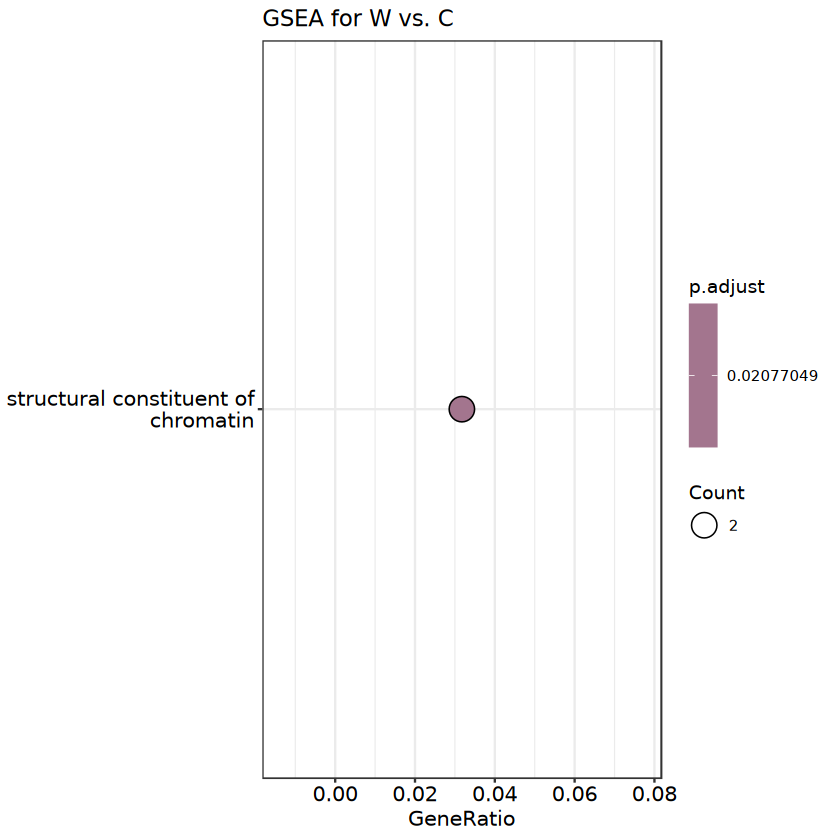

In [16]:
dotplot(gsea_res_w.c, showCategory=20) + ggtitle('GSEA for W vs. C')

### Both vs. Control

In [17]:
# both vs control
gsea_res_b.c <- GSEA(
    geneList = b.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_b.c)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.94% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Hypoxic vs. Control

In [18]:
# hypoxic vs control
gsea_res_h.c <- GSEA(
    geneList = h.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_h.c)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.9% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Hypoxic vs. Both

In [19]:
# hypoxic vs both
gsea_res_h.b <- GSEA(
    geneList = h.b_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_h.b)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.54% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Warm vs. Both

In [20]:
# warm vs both
gsea_res_w.b <- GSEA(
    geneList = w.b_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_w.b)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.51% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Warm vs. Hypoxic

In [21]:
# warm vs hypoxic
gsea_res_w.h <- GSEA(
    geneList = w.h_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_w.h)

preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (1.11% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

# Over Representation Analysis

using `enricher` from clusterProfiler to do an over-representation analysis on DEGs

#### Are there any *gene sets* that are over-represented in the identified differential expressed genes (DEGs) than would be expected by chance?

## 1. pull DEGs

In [22]:
head(w.h)

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,LOC144621260,2772.7661933,0.051218621,0.1224117,0.6653711,0.5058132,0.8806943,0.9926832,2271.416959,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,2,LOC144621269,6797.3813723,0.032231978,0.1938035,1.0902191,0.2756166,0.7670156,0.9810406,497.327987,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,3,LOC111120925,191.4430470,0.031224687,0.1966004,1.0924208,0.2746482,0.7663446,0.9805628,3.429848,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,4,Trnae-cuc,0.0000000,0.000000000,1.1798226,NA,NA,NA,0.9734790,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,5,Trnae-cuc-2,0.0000000,0.000000000,1.1798226,NA,NA,NA,0.9441227,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,6,Trnae-cuc-3,0.3001343,0.009795103,0.2749392,0.5927874,0.5533234,NA,0.9794512,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


In [27]:
# make list of dfs
comps <- list(w.c, h.c, b.c, h.b, w.b, w.h)
names(comps) <- c('w.c', 'h.c', 'b.c', 'h.b', 'w.b', 'w.h')
head(comps$w.c)

,X,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,LOC144621260,2772.7661933,0.0041376006,0.05479417,0.27170722,0.78584715,0.9866898,0.9914836,2271.416959,⋯,3206.1520,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,2,LOC144621269,6797.3813723,0.0042846374,0.10625915,0.45989202,0.64559373,0.9763304,0.9837326,497.327987,⋯,9120.5983,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,3,LOC111120925,191.4430470,-0.1617284107,0.65118025,-2.57799792,0.00993746,0.3655716,0.6796401,3.429848,⋯,383.2612,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,4,Trnae-cuc,0.0000000,0.0000000000,1.09814472,NA,NA,NA,0.9421386,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
5,5,Trnae-cuc-2,0.0000000,0.0000000000,1.09814472,NA,NA,NA,0.9421521,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000
6,6,Trnae-cuc-3,0.3001343,0.0002446391,0.22593887,0.01996082,0.98407463,NA,0.9788322,0.000000,⋯,0.0000,0.00000,0.0000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000


In [23]:
# function to find DEGs
find_degs <- function(df) {
    df %>% filter(
        abs(log2FoldChange) > 1 &
        padj < 0.05) %>%
    pull(Gene)
    }

In [30]:
comps.degs <- lapply(comps, find_degs)
length(comps.degs$w.c)
head(comps.degs$w.c)

[1] 89

[1] "LOC144621391" "LOC111103995" "LOC144622019" "LOC111105159" "LOC111137262"
[6] "LOC111103105"

## 2. run `enricher` from clusterProfiler

### Warm vs. Control

In [32]:
# warm vs. control
res_sig.w.c <- enricher(
    gene = comps.degs$w.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.c$Gene)

w.c_ora <- as.data.frame(res_sig.w.c)
head(w.c_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO term

### Hypoxic vs. Control

In [33]:
# hypoxic vs. control
res_sig.h.c <- enricher(
    gene = comps.degs$h.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = h.c$Gene)

h.c_ora <- as.data.frame(res_sig.h.c)

head(h.c_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

### Both vs. Control

In [39]:
# both vs. control
res_sig.b.c <- enricher(
    gene = comps.degs$b.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = b.c$Gene)

b.c_ora <- as.data.frame(res_sig.b.c)

head(b.c_ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005975,GO:0005975,carbohydrate metabolic process,7/103,101/12538,1.879273e-05,0.001935651,0.001760582,LOC111127514/LOC111125217/LOC111100804/LOC111133166/LOC111136394/LOC111136393/LOC111134018,7
GO:0004100,GO:0004100,chitin synthase activity,3/103,18/12538,4.016678e-04,0.010342947,0.009407484,LOC111125340/LOC111125343/LOC111125342,3
GO:0006031,GO:0006031,chitin biosynthetic process,3/103,18/12538,4.016678e-04,0.010342947,0.009407484,LOC111125340/LOC111125343/LOC111125342,3
GO:0030428,GO:0030428,cell septum,3/103,18/12538,4.016678e-04,0.010342947,0.009407484,LOC111125340/LOC111125343/LOC111125342,3
GO:0004553,GO:0004553,"hydrolase activity, hydrolyzing O-glycosyl compounds",3/103,21/12538,6.430617e-04,0.013247071,0.012048945,LOC111100804/LOC111133166/LOC111134018,3
GO:0071944,GO:0071944,cell periphery,3/103,24/12538,9.612665e-04,0.015649106,0.014233729,LOC111125340/LOC111125343/LOC111125342,3


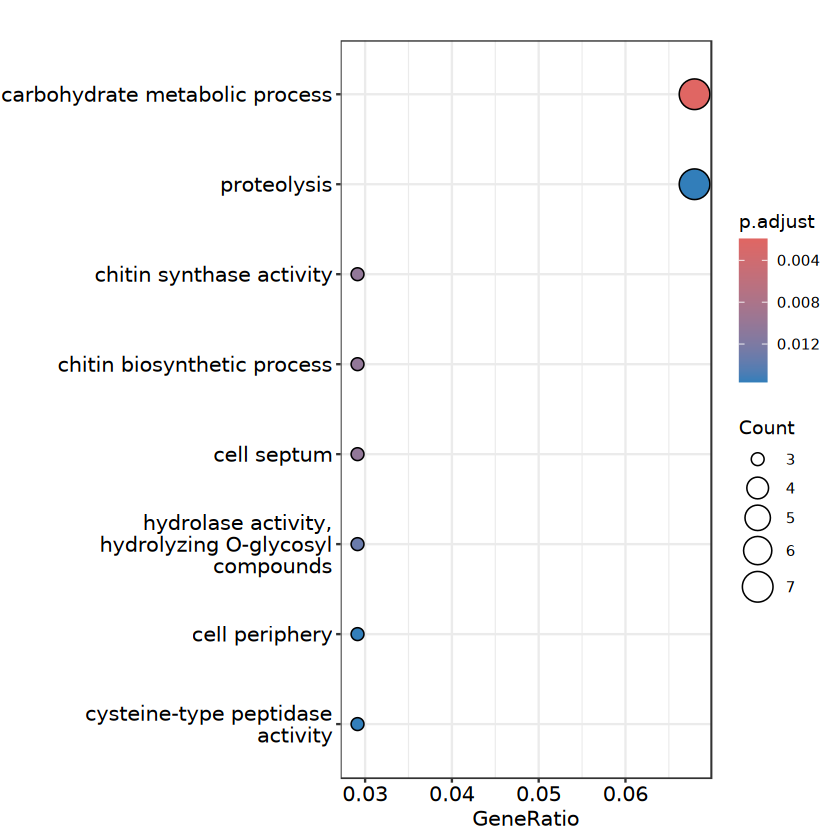

In [41]:
dotplot(res_sig.b.c)

lots of GO terms!! And we see 2 significantly over-represented GO terms involved in chitin processes (and 1 for carbs which is likely related to chitin)

### Hypoxic vs. Both

In [43]:
# hypoxic vs. both
res_sig.h.b <- enricher(
    gene = comps.degs$h.b,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = h.b$Gene)

h.b_ora <- as.data.frame(res_sig.h.b)

head(h.b_ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0004100,GO:0004100,chitin synthase activity,2/53,18/12538,0.002568720,0.04530499,0.03988574,LOC111125340/LOC111125342,2
GO:0006031,GO:0006031,chitin biosynthetic process,2/53,18/12538,0.002568720,0.04530499,0.03988574,LOC111125340/LOC111125342,2
GO:0030428,GO:0030428,cell septum,2/53,18/12538,0.002568720,0.04530499,0.03988574,LOC111125340/LOC111125342,2
GO:0004553,GO:0004553,"hydrolase activity, hydrolyzing O-glycosyl compounds",2/53,21/12538,0.003497222,0.04530499,0.03988574,LOC111133166/LOC111134018,2
GO:0071944,GO:0071944,cell periphery,2/53,24/12538,0.004559262,0.04530499,0.03988574,LOC111125340/LOC111125342,2
GO:0008234,GO:0008234,cysteine-type peptidase activity,2/53,25/12538,0.004942363,0.04530499,0.03988574,LOC111113029/LOC111113026,2


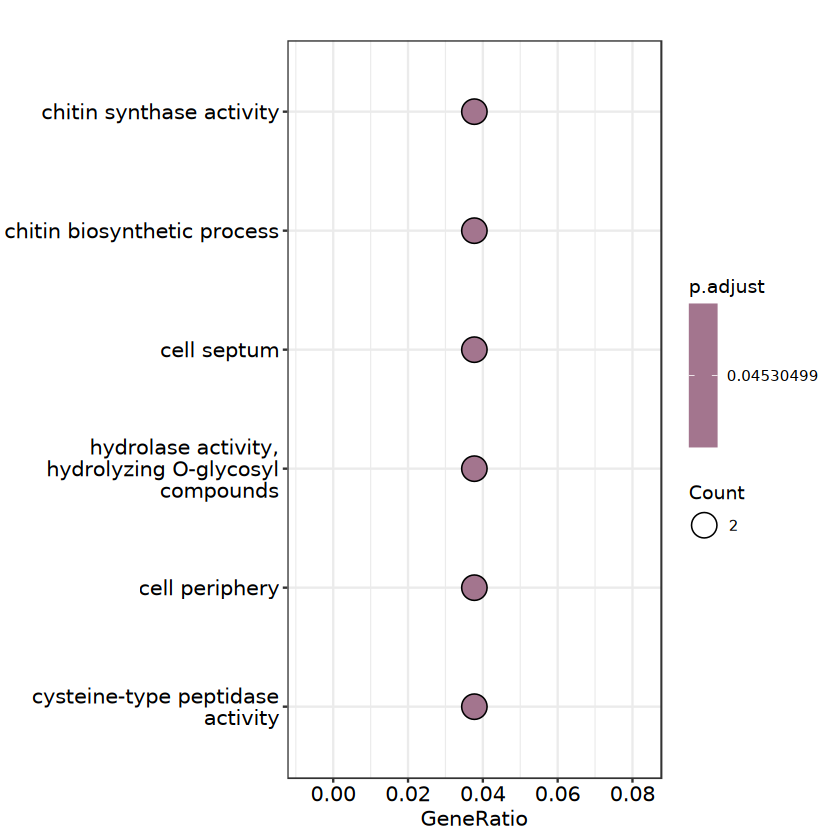

In [44]:
dotplot(res_sig.h.b)

more chitin terms! so probably due to the both treatment

### Warm vs. Both

In [45]:
# warm vs. both
res_sig.w.b <- enricher(
    gene = comps.degs$w.b,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.b$Gene)

w.b_ora <- as.data.frame(res_sig.w.b)

head(w.b_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

### Warm vs. Hypoxic

In [46]:
# warm vs. hypoxic
res_sig.w.h <- enricher(
    gene = comps.degs$w.h,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

w.h_ora <- as.data.frame(res_sig.w.h)

head(w.h_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

# I STOPPED HERE

## ORA in Up- or Down-Regulated DEGs
basically repeating the above section, but splitting the DEG sets into up- or down- regulated to look at patterns there

(only doing this for comparisons against control for simplicity)

### Phase 1 Warm vs. Control

In [33]:
w.c_up <- w.c_deg %>%
filter(log2FoldChange > 0)
w.c_up <- w.c_up$X
head(w.c_up)

w.c_down <- w.c_deg %>%
filter(log2FoldChange < 0)
w.c_down <- w.c_down$X
head(w.c_down)

[1] "LOC111121183" "LOC111106303" "LOC111122541" "LOC111130453" "LOC111120021"
[6] "LOC111135464"

[1] "LOC111129171" "LOC111135260" "LOC111104602" "LOC111101935" "LOC111119500"
[6] "LOC111120933"

In [34]:
# warm vs. control UP
w.c_up.res <- enricher(
    gene = w.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

w.c_up.ora <- as.data.frame(w.c_up.res)

head(w.c_up.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005975,GO:0005975,carbohydrate metabolic process,3/15,141/16641,0.0002514545,0.01904918,0.01023332,LOC111135464/LOC111100804/LOC111125414,3
GO:0004553,GO:0004553,"hydrolase activity, hydrolyzing O-glycosyl compounds",2/15,27/16641,0.0002627474,0.01904918,0.01023332,LOC111135464/LOC111100804,2
GO:0004089,GO:0004089,carbonate dehydratase activity,2/15,35/16641,0.0004435465,0.02143808,0.01151664,LOC111137424/LOC111117514,2


In [35]:
# warm vs. control DOWN
w.c_down.res <- enricher(
    gene = w.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

w.c_down.ora <- as.data.frame(w.c_down.res)

head(w.c_down.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0004869,GO:0004869,cysteine-type endopeptidase inhibitor activity,3/14,11/16641,7.790285e-08,5.297394e-06,3.116114e-06,LOC111114881/LOC111113359/LOC111117444,3
GO:0010466,GO:0010466,negative regulation of peptidase activity,3/14,67/16641,2.199791e-05,7.479291e-04,4.399583e-04,LOC111114881/LOC111113359/LOC111117444,3
GO:0033691,GO:0033691,sialic acid binding,2/14,14/16641,5.946671e-05,1.347912e-03,7.928895e-04,LOC111125904/LOC111123027,2
GO:0043654,GO:0043654,recognition of apoptotic cell,2/14,85/16641,2.254668e-03,3.832936e-02,2.254668e-02,LOC111125904/LOC111117000,2


In [36]:
w.c_down.ora$direction <- 'Down-Regulated DEGs'
w.c_up.ora$direction <- 'Up-Regulated DEGs'

w.c.ora <- rbind(w.c_up.ora, w.c_down.ora)
head(w.c.ora, 2)
tail(w.c.ora,2)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0005975,GO:0005975,carbohydrate metabolic process,3/15,141/16641,0.0002514545,0.01904918,0.01023332,LOC111135464/LOC111100804/LOC111125414,3,Up-Regulated DEGs
GO:0004553,GO:0004553,"hydrolase activity, hydrolyzing O-glycosyl compounds",2/15,27/16641,0.0002627474,0.01904918,0.01023332,LOC111135464/LOC111100804,2,Up-Regulated DEGs


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0033691,GO:0033691,sialic acid binding,2/14,14/16641,5.946671e-05,0.001347912,0.0007928895,LOC111125904/LOC111123027,2,Down-Regulated DEGs
GO:0043654,GO:0043654,recognition of apoptotic cell,2/14,85/16641,2.254668e-03,0.038329358,0.0225466809,LOC111125904/LOC111117000,2,Down-Regulated DEGs


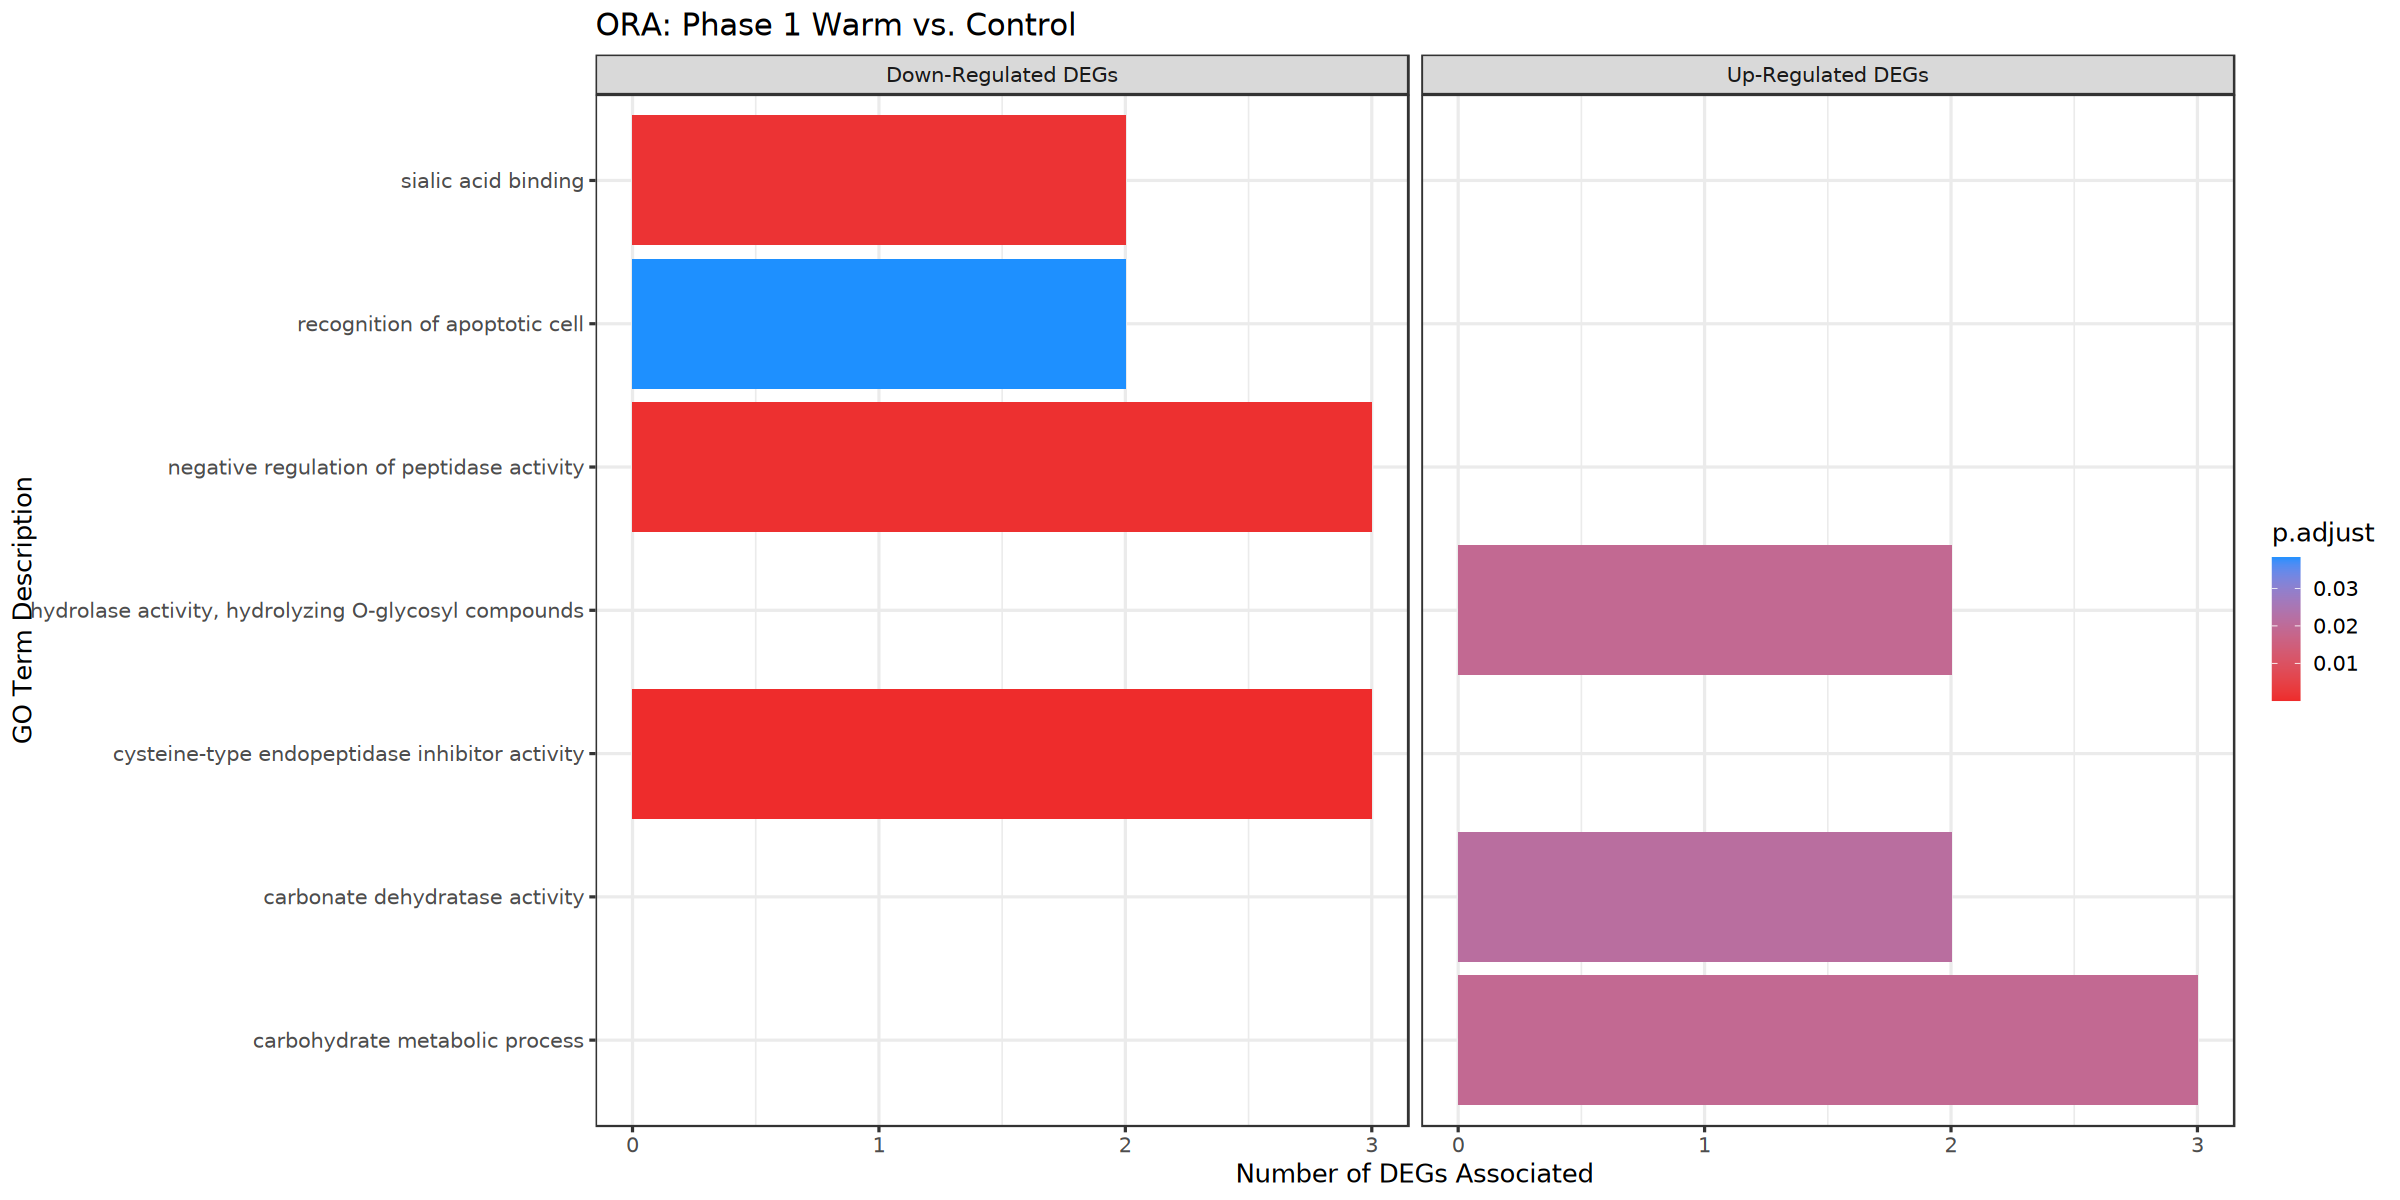

In [37]:
options(repr.plot.width=20, repr.plot.height=10)

w.c.bar <- ggplot(w.c.ora, aes(x=Description, y=Count)) +
geom_bar(stat = "identity", aes(fill=p.adjust)) + 
scale_fill_gradient(low = 'firebrick2', high = 'dodgerblue') +
coord_flip() +
theme_bw(base_size=15) +
facet_wrap(~direction) +
labs(title = 'ORA: Phase 1 Warm vs. Control',
    x = 'GO Term Description',
    y = 'Number of DEGs Associated')

w.c.bar

In [70]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/ORA.wc.directional_bar.pdf', w.c.bar, width = 20, height = 10)

### Phase 1 Hypoxic vs. Control

In [39]:
h.c_up <- h.c_deg %>%
filter(log2FoldChange > 0)
h.c_up <- h.c_up$X
head(h.c_up)

h.c_down <- h.c_deg %>%
filter(log2FoldChange < 0)
h.c_down <- h.c_down$X
head(h.c_down)

[1] "LOC111121183" "LOC111120021" "LOC111119724" "LOC111119726" "LOC111125414"
[6] "LOC111123780"

[1] "LOC111138278" "LOC111134915" "LOC111132199" "LOC111100048" "LOC111105273"
[6] "LOC111102795"

In [40]:
# warm vs. control UP
h.c_up.res <- enricher(
    gene = h.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

h.c_up.ora <- as.data.frame(h.c_up.res)

head(h.c_up.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0009751,GO:0009751,response to salicylic acid,1/6,10/16641,0.003600680,0.04681457,0.01137196,LOC111105743,1
GO:0015802,GO:0015802,basic amino acid transport,1/6,10/16641,0.003600680,0.04681457,0.01137196,LOC111125414,1
GO:0015174,GO:0015174,basic amino acid transmembrane transporter activity,1/6,13/16641,0.004678775,0.04681457,0.01137196,LOC111125414,1
GO:0015810,GO:0015810,aspartate transmembrane transport,1/6,14/16641,0.005037924,0.04681457,0.01137196,LOC111125414,1
GO:0005768,GO:0005768,endosome,2/6,319/16641,0.005221839,0.04681457,0.01137196,LOC111112437/LOC111112788,2
GO:0030422,GO:0030422,siRNA processing,1/6,17/16641,0.006114723,0.04681457,0.01137196,LOC111105743,1


In [41]:
# warm vs. control DOWN
h.c_down.res <- enricher(
    gene = h.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

h.c_down.ora <- as.data.frame(h.c_down.res)

head(h.c_down.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0014731,GO:0014731,spectrin-associated cytoskeleton,2/3,135/16641,0.0001949425,0.005668733,0.0005496002,LOC111105823/LOC111113858,2
GO:0016529,GO:0016529,sarcoplasmic reticulum,2/3,154/16641,0.0002537159,0.005668733,0.0005496002,LOC111105823/LOC111113858,2
GO:0030507,GO:0030507,spectrin binding,2/3,161/16641,0.0002773057,0.005668733,0.0005496002,LOC111105823/LOC111113858,2
GO:0005200,GO:0005200,structural constituent of cytoskeleton,2/3,167/16641,0.0002983544,0.005668733,0.0005496002,LOC111105823/LOC111113858,2
GO:0044325,GO:0044325,transmembrane transporter binding,2/3,231/16641,0.0005703286,0.007667434,0.0007433801,LOC111105823/LOC111113858,2
GO:0072659,GO:0072659,protein localization to plasma membrane,2/3,238/16641,0.0006053238,0.007667434,0.0007433801,LOC111105823/LOC111113858,2


In [42]:
h.c_down.ora$direction <- 'Down-Regulated DEGs'
h.c_up.ora$direction <- 'Up-Regulated DEGs'

h.c.ora <- rbind(h.c_up.ora, h.c_down.ora)
head(h.c.ora, 2)
tail(h.c.ora,2)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0009751,GO:0009751,response to salicylic acid,1/6,10/16641,0.00360068,0.04681457,0.01137196,LOC111105743,1,Up-Regulated DEGs
GO:0015802,GO:0015802,basic amino acid transport,1/6,10/16641,0.00360068,0.04681457,0.01137196,LOC111125414,1,Up-Regulated DEGs


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0019903,GO:0019903,protein phosphatase binding,1/3,228/16641,0.04054511,0.04531513,0.004393433,LOC111113858,1,Down-Regulated DEGs
GO:0045296,GO:0045296,cadherin binding,1/3,235/16641,0.04177226,0.04601003,0.004460806,LOC111105823,1,Down-Regulated DEGs


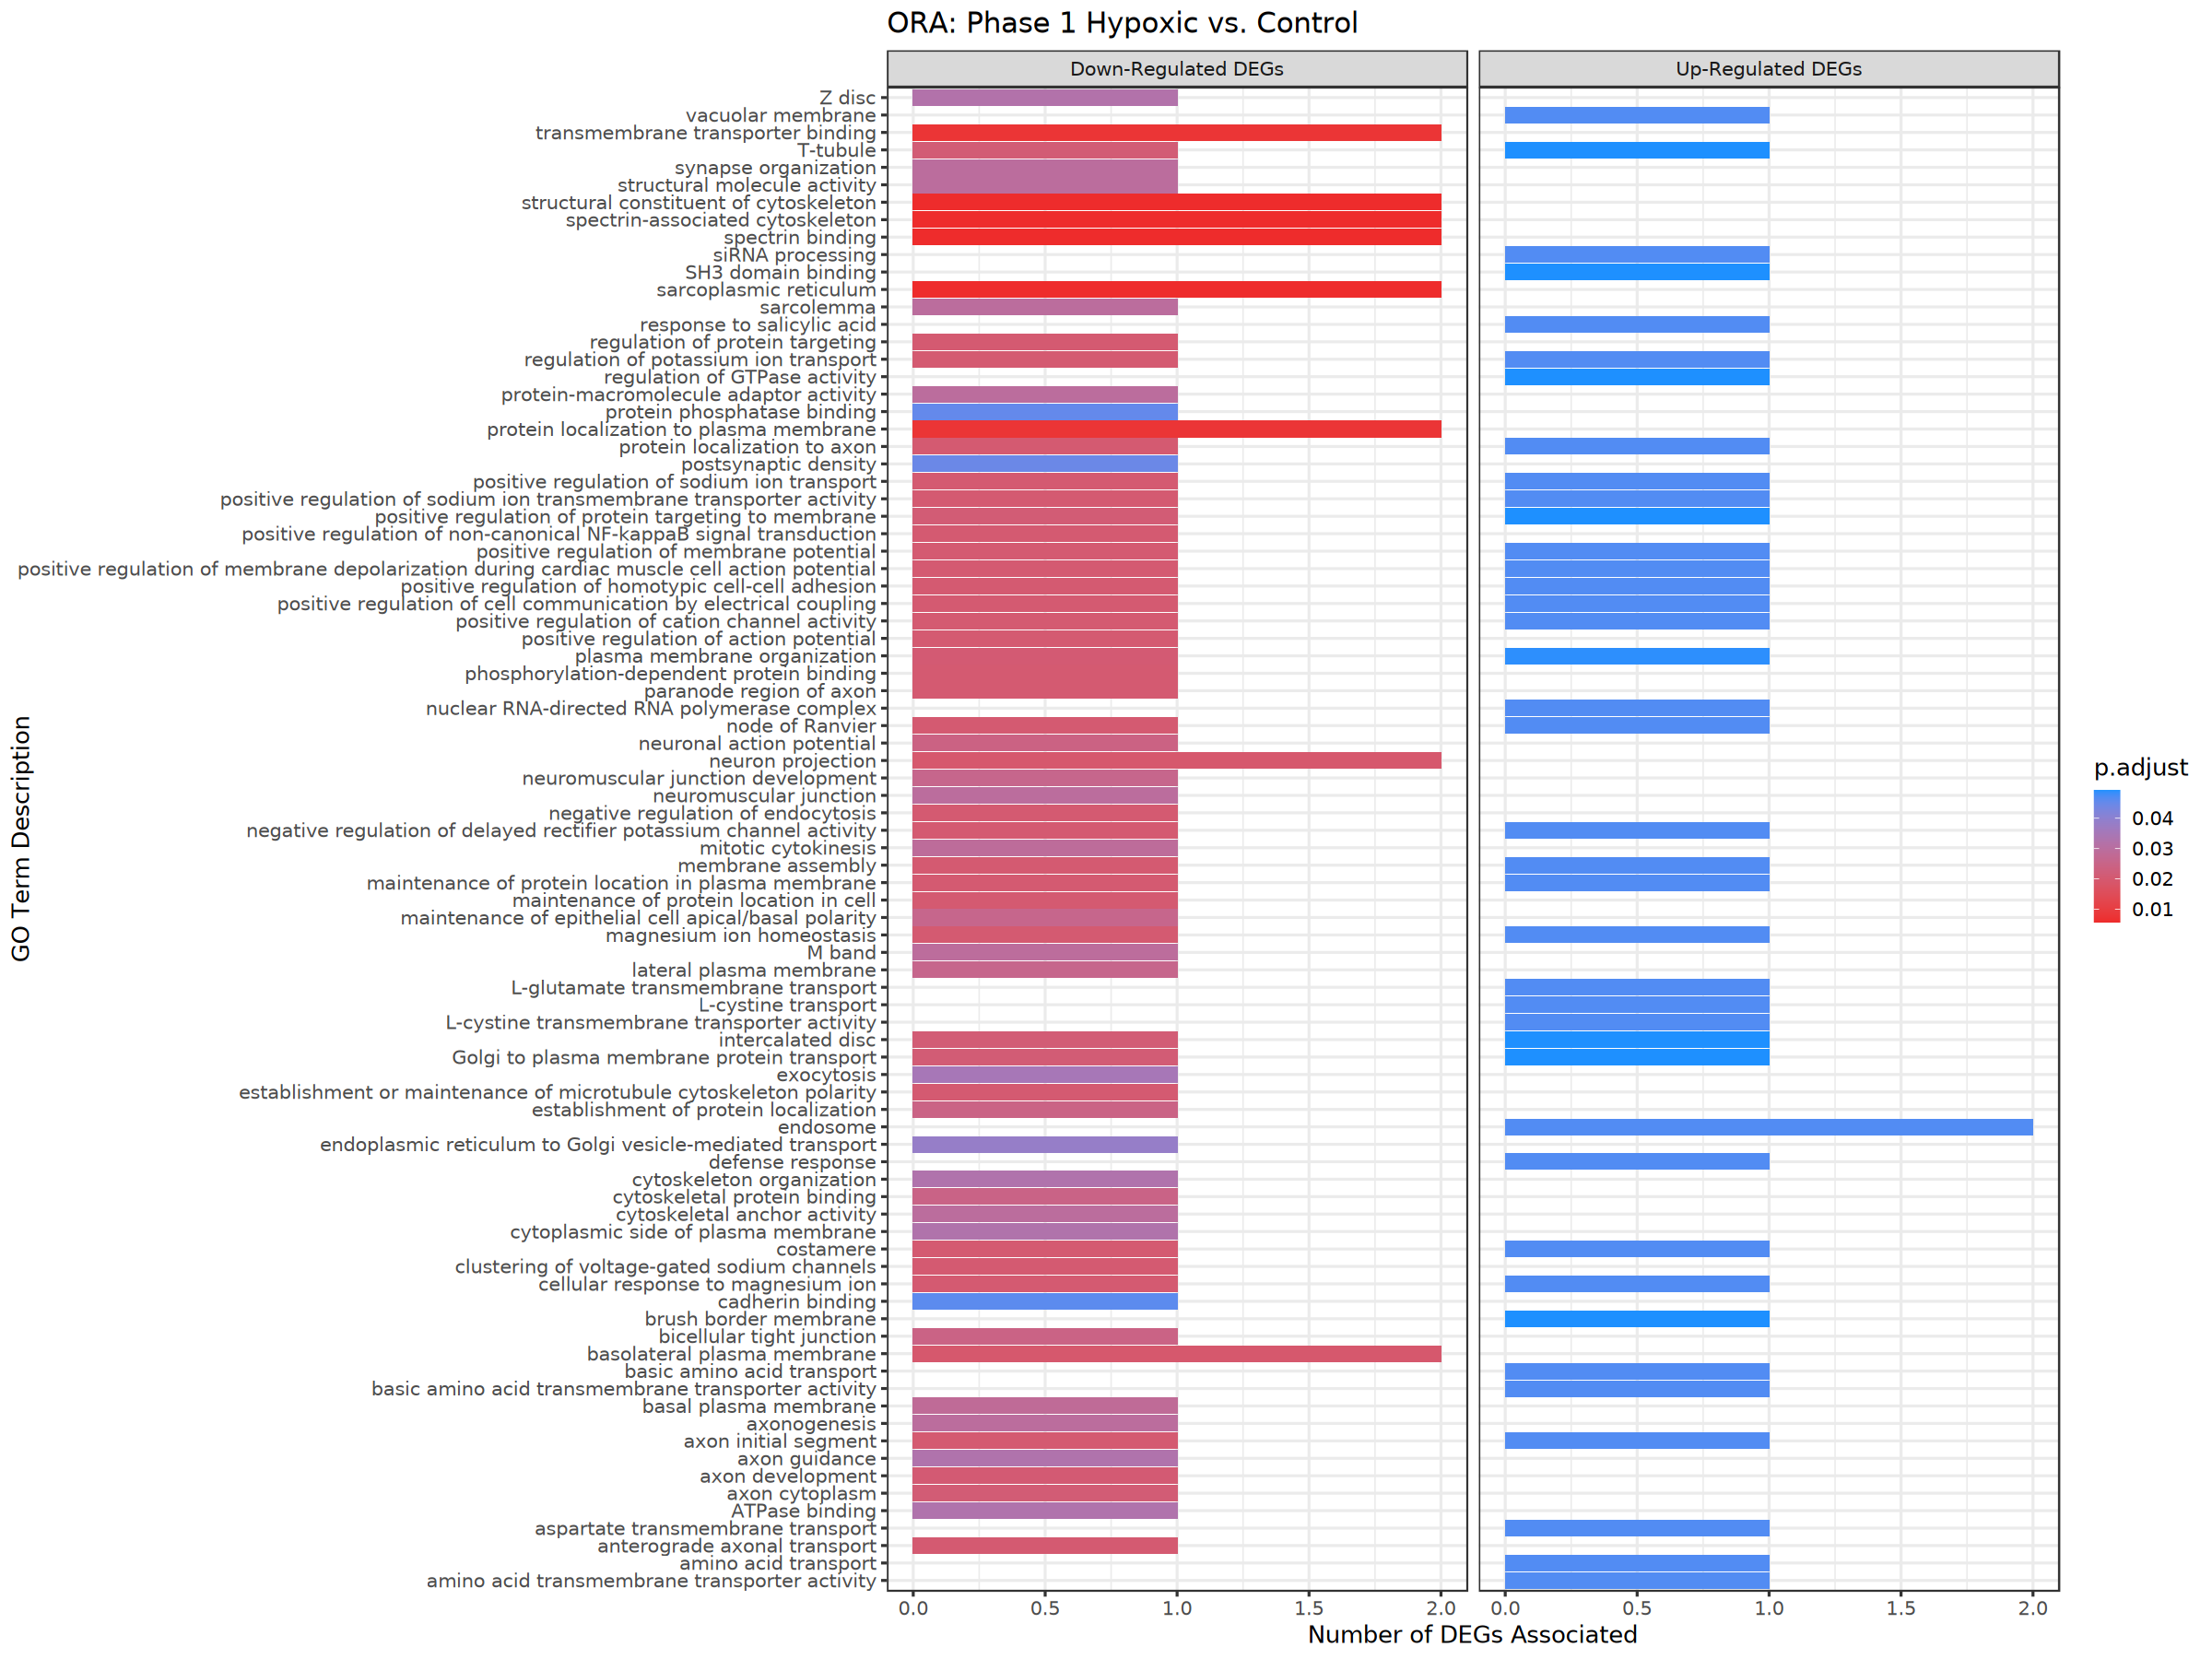

In [43]:
options(repr.plot.width=20, repr.plot.height=15)

h.c.bar <- ggplot(h.c.ora, aes(x=Description, y=Count)) +
geom_bar(stat = "identity", aes(fill=p.adjust)) + 
scale_fill_gradient(low = 'firebrick2', high = 'dodgerblue') +
coord_flip() +
theme_bw(base_size=15) +
facet_wrap(~direction) +
labs(title = 'ORA: Phase 1 Hypoxic vs. Control',
    x = 'GO Term Description',
    y = 'Number of DEGs Associated')

h.c.bar

In [71]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/ORA.hc.directional_bar.pdf', h.c.bar, width = 20, height = 10)

### Phase 1 Both vs. Control

In [45]:
b.c_up <- b.c_deg %>%
filter(log2FoldChange > 0)
b.c_up <- b.c_up$X
head(b.c_up)

b.c_down <- b.c_deg %>%
filter(log2FoldChange < 0)
b.c_down <- b.c_down$X
head(b.c_down)

[1] "LOC111104630" "LOC111121183" "LOC111130465" "LOC111120021" "LOC111120117"
[6] "LOC111134586"

[1] "LOC111119645" "LOC111111234" "LOC111129171" "LOC111111721" "LOC111111747"
[6] "LOC111106320"

In [46]:
# both vs. control UP
b.c_up.res <- enricher(
    gene = b.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

b.c_up.ora <- as.data.frame(b.c_up.res)

head(b.c_up.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0030422,GO:0030422,siRNA processing,2/21,17/16641,0.000203937,0.01631496,0.01062619,LOC111108349/LOC111105743,2
GO:0031380,GO:0031380,nuclear RNA-directed RNA polymerase complex,2/21,17/16641,0.000203937,0.01631496,0.01062619,LOC111108349/LOC111105743,2


In [47]:
# both vs. control DOWN
b.c_down.res <- enricher(
    gene = b.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

b.c_down.ora <- as.data.frame(b.c_down.res)

head(b.c_down.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0004568,GO:0004568,chitinase activity,4/85,24/16641,6.230726e-06,0.003090440,0.002597229,LOC111119837/LOC111124157/LOC111125216/LOC111125215,4
GO:0000272,GO:0000272,polysaccharide catabolic process,4/85,34/16641,2.615540e-05,0.004066022,0.003417115,LOC111119837/LOC111124157/LOC111125216/LOC111125215,4
GO:0002532,GO:0002532,production of molecular mediator involved in inflammatory response,3/85,12/16641,2.737008e-05,0.004066022,0.003417115,LOC111124157/LOC111125216/LOC111125215,3
GO:0032722,GO:0032722,positive regulation of chemokine production,3/85,13/16641,3.544982e-05,0.004066022,0.003417115,LOC111124157/LOC111125216/LOC111125215,3
GO:0006032,GO:0006032,chitin catabolic process,4/85,38/16641,4.098813e-05,0.004066022,0.003417115,LOC111119837/LOC111124157/LOC111125216/LOC111125215,4
GO:0008061,GO:0008061,chitin binding,4/85,53/16641,1.533983e-04,0.012005428,0.010089452,LOC111119837/LOC111124157/LOC111125216/LOC111125215,4


In [48]:
b.c_down.ora$direction <- 'Down-Regulated DEGs'
b.c_up.ora$direction <- 'Up-Regulated DEGs'

b.c.ora <- rbind(b.c_up.ora, b.c_down.ora)
head(b.c.ora, 2)
tail(b.c.ora,2)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0030422,GO:0030422,siRNA processing,2/21,17/16641,0.000203937,0.01631496,0.01062619,LOC111108349/LOC111105743,2,Up-Regulated DEGs
GO:0031380,GO:0031380,nuclear RNA-directed RNA polymerase complex,2/21,17/16641,0.000203937,0.01631496,0.01062619,LOC111108349/LOC111105743,2,Up-Regulated DEGs


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>
GO:0030414,GO:0030414,peptidase inhibitor activity,2/85,10/16641,0.001129847,0.04670036,0.03924733,LOC111099569/LOC111099841,2,Down-Regulated DEGs
GO:0098632,GO:0098632,cell-cell adhesion mediator activity,2/85,10/16641,0.001129847,0.04670036,0.03924733,LOC111125416/LOC111125415,2,Down-Regulated DEGs


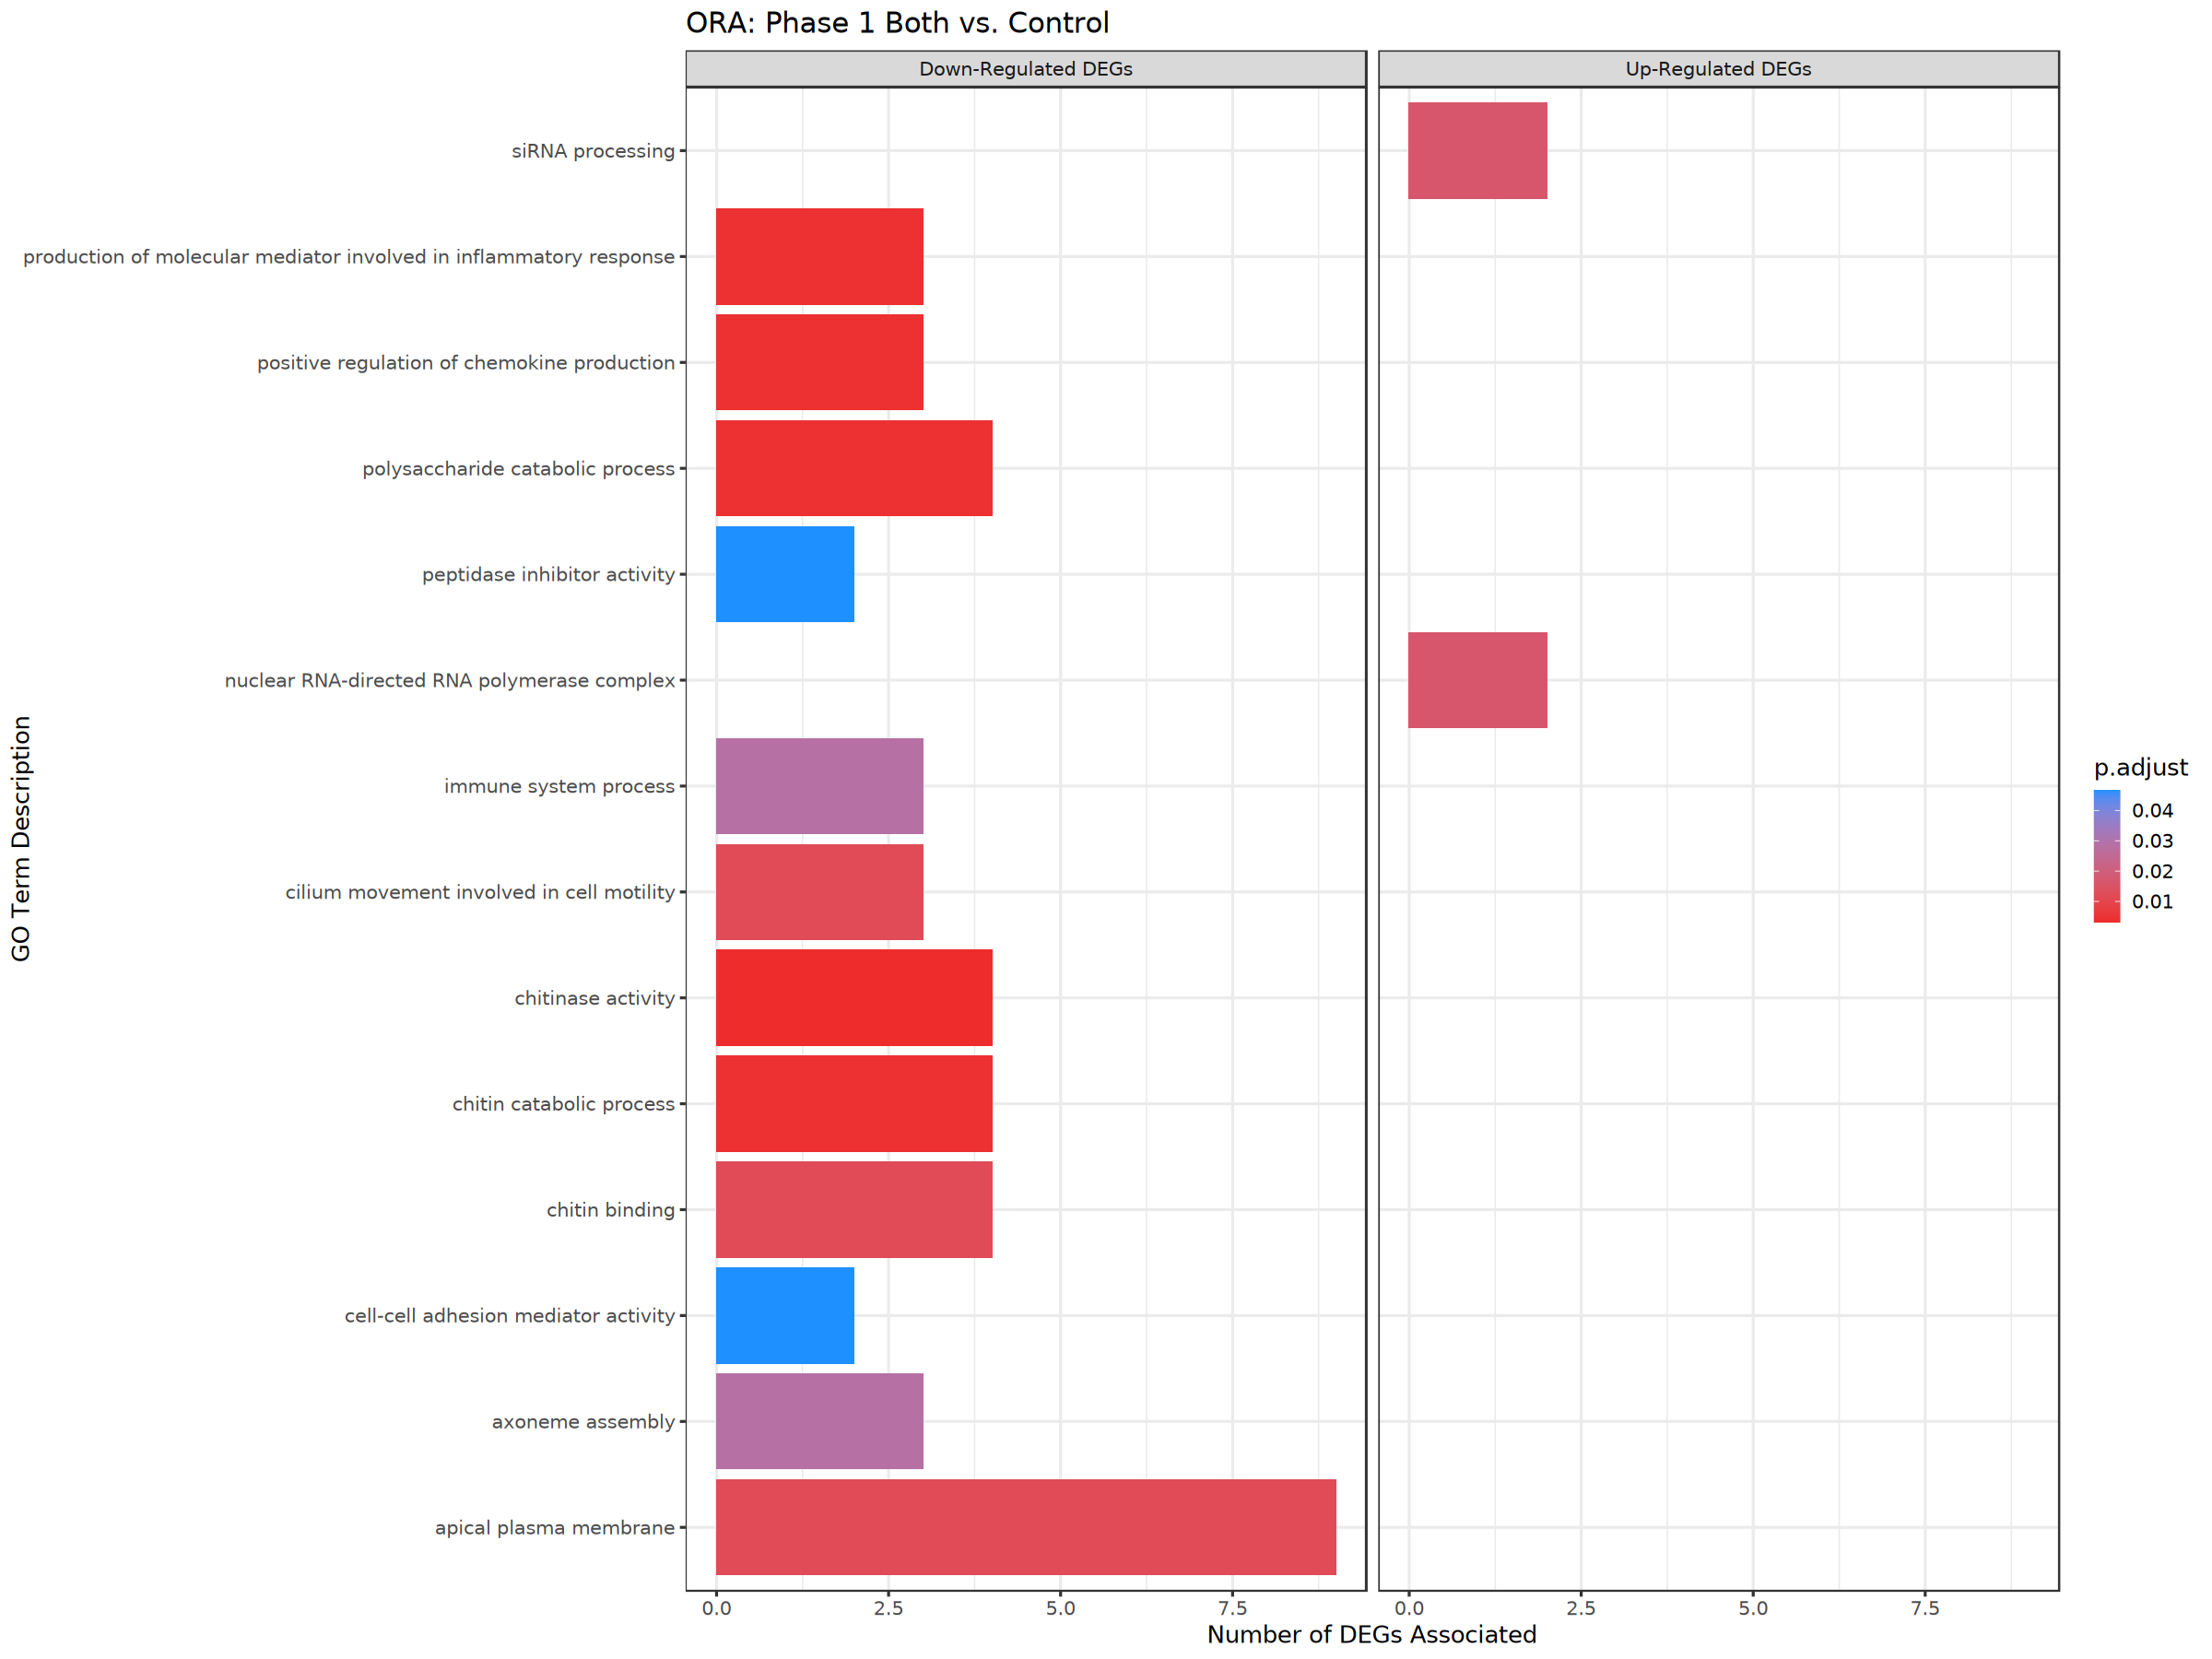

In [49]:
options(repr.plot.width=20, repr.plot.height=15)

b.c.bar <- ggplot(b.c.ora, aes(x=Description, y=Count)) +
geom_bar(stat = "identity", aes(fill=p.adjust)) + 
scale_fill_gradient(low = 'firebrick2', high = 'dodgerblue') +
coord_flip() +
theme_bw(base_size=15) +
facet_wrap(~direction) +
labs(title = 'ORA: Phase 1 Both vs. Control',
    x = 'GO Term Description',
    y = 'Number of DEGs Associated')

b.c.bar

In [72]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/ORA.bc.directional_bar.pdf', b.c.bar, width = 20, height = 10)

there's 3 GO terms that have to do with chitin (12 DEGs that are over-represented for chitin-related processes) which is interesting - chitin is a polysaccharide that is typically used for structural support and is found in oyster shells